### Import necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.metrics import confusion_matrix
import glob

### Fetch the training Data

In [2]:
buildings = glob.glob("seg_train/seg_train/buildings/*.jpg")
forest    = glob.glob("seg_train/seg_train/forest/*.jpg")
glacier   = glob.glob("seg_train/seg_train/glacier/*.jpg")
mountain  = glob.glob("seg_train/seg_train/mountain/*.jpg")
sea       = glob.glob("seg_train/seg_train/sea/*.jpg")
street    = glob.glob("seg_train/seg_train/street/*.jpg")

### Fetch the testing data

In [3]:
buildings_test = glob.glob("seg_test/seg_test/buildings/*.jpg")
forest_test    = glob.glob("seg_test/seg_test/forest/*.jpg")
glacier_test   = glob.glob("seg_test/seg_test/glacier/*.jpg")
mountain_test  = glob.glob("seg_test/seg_test/mountain/*.jpg")
sea_test       = glob.glob("seg_test/seg_test/sea/*.jpg")
street_test    = glob.glob("seg_test/seg_test/street/*.jpg")

### Find the number of images of all classes in the Training set

In [4]:
len(buildings), len(forest), len(glacier), len(mountain), len(sea), len(street)

(2191, 2271, 2404, 2512, 2274, 2382)

### Spliting into training and testing sets

In [5]:
def split_data(data, train_ratio=0.8):
    split_index = int(len(data) * train_ratio)
    return data[:split_index], data[split_index:]

In [6]:
buildings_train, buildings_test = split_data(buildings)
forest_train, forest_test = split_data(forest)
glacier_train, glacier_test = split_data(glacier)
mountain_train, mountain_test = split_data(mountain)
sea_train, sea_test = split_data(sea)
street_train, street_test = split_data(street)

### Store all the images inside a list and create a list with the corresponding labels

In [7]:
images = []
labels = []

for i in buildings_train:
    img = plt.imread(i)
    images.append(img)
    labels.append(0)

for i in forest_train:
    img = plt.imread(i)
    images.append(img)
    labels.append(1)

for i in glacier_train:
    img = plt.imread(i)
    images.append(img)
    labels.append(2)

for i in mountain_train:
    img = plt.imread(i)
    images.append(img)
    labels.append(3)

for i in sea_train:
    img = plt.imread(i)
    images.append(img)
    labels.append(4)

for i in street_train:
    img = plt.imread(i)
    images.append(img)
    labels.append(5)

In [8]:
images_test = []
labels_test = []

for i in buildings_test:
    img = plt.imread(i)
    images_test.append(img)
    labels_test.append(0)

for i in forest_test:
    img = plt.imread(i)
    images_test.append(img)
    labels_test.append(1)

for i in glacier_test:
    img = plt.imread(i)
    images_test.append(img)
    labels_test.append(2)

for i in mountain_test:
    img = plt.imread(i)
    images_test.append(img)
    labels_test.append(3)

for i in sea_test:
    img = plt.imread(i)
    images_test.append(img)
    labels_test.append(4)

for i in street_test:
    img = plt.imread(i)
    images_test.append(img)
    labels_test.append(5)

### Shuffle the images

In [9]:
from sklearn.utils import shuffle

In [10]:
images, labels = shuffle(images, labels, random_state=42)

In [11]:
images_test, labels_test = shuffle(images_test, labels_test, random_state=42)

In [12]:
label_names = {0:"buildings",1:"forest",2:"glacier",3:"mountain",4:"sea",5:"street"}

### Plot a few images from our shuffled list with its corresponding label

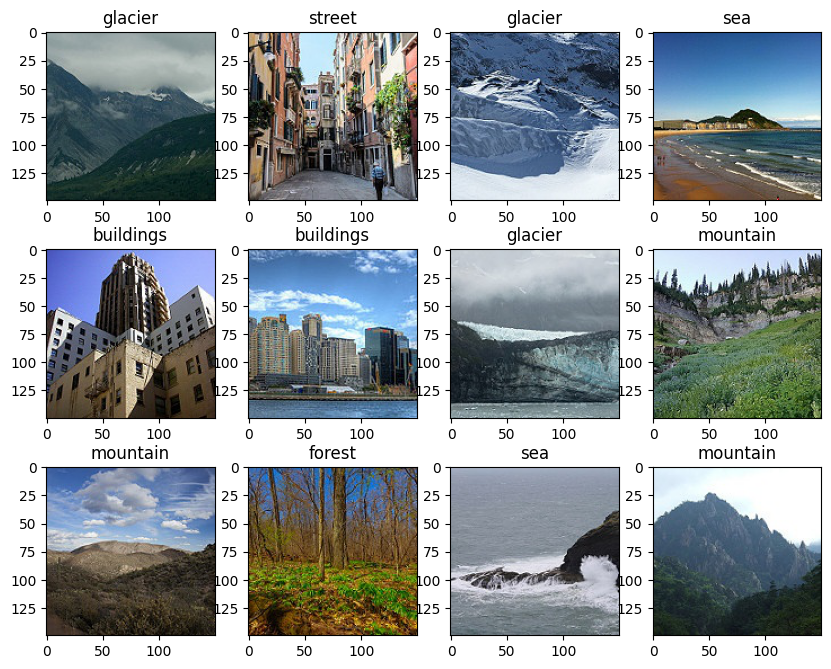

In [13]:
plt.figure(figsize=(10,8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(label_names[labels[i]])

In [14]:
for i in range(min(10, len(images))):
        print(images[i].shape)

(150, 150, 3)
(150, 150, 3)
(150, 150, 3)
(150, 150, 3)
(150, 150, 3)
(150, 150, 3)
(150, 150, 3)
(150, 150, 3)
(150, 150, 3)
(150, 150, 3)


### Resizing the images

In [15]:
from skimage.transform import resize

In [16]:
x_train = []
for i in images:
    x_train.append(resize(i, (64, 64, 3)))

In [17]:
x_test = []
for i in images_test:
    x_test.append(resize(i, (64, 64, 3)))

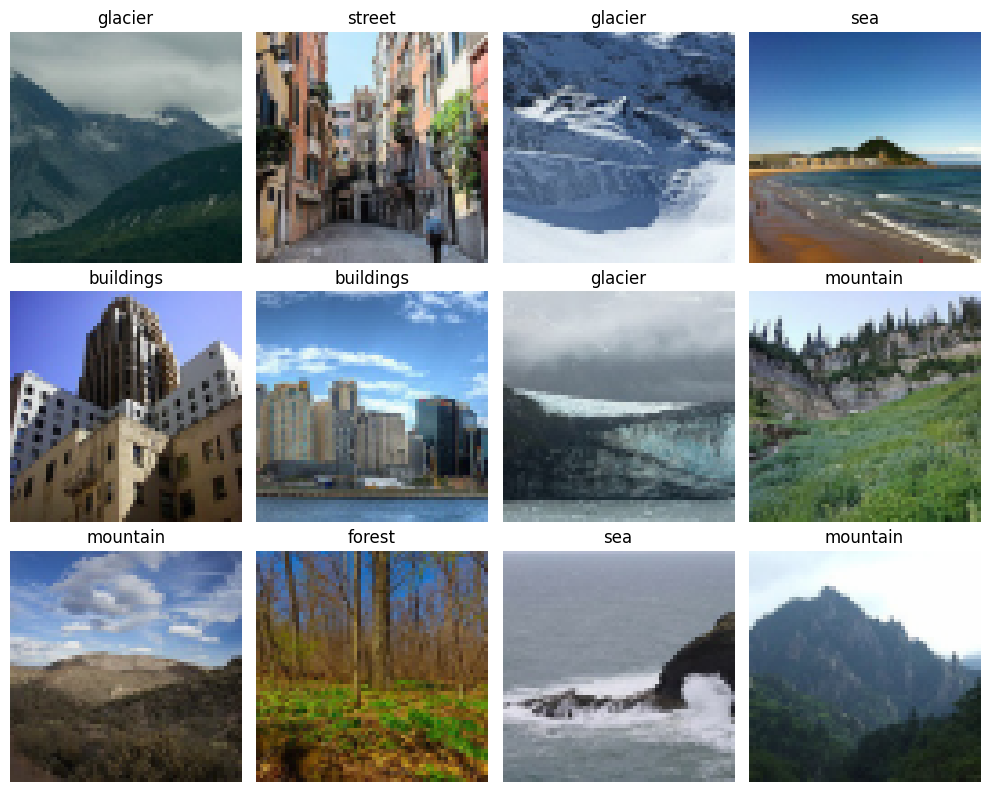

In [18]:
plt.figure(figsize=(10,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_train[i])
    plt.title(label_names[labels[i]])   
    plt.axis('off')
plt.tight_layout()
plt.show()

### Create numpy arrays named y_train and y_test from our training and testing label lists we created earlier

In [19]:
x_train = np.array(x_train)
x_test = np.array(x_test)

In [20]:
y_train = np.array(labels)
y_test = np.array(labels_test)

In [21]:
print(f'x_train shape = {x_train.shape}')
print(f'x_test shape = {x_test.shape}')
print(f'y_train shape = {y_train.shape}')
print(f'y_test shape = {y_test.shape}')

x_train shape = (11224, 64, 64, 3)
x_test shape = (2810, 64, 64, 3)
y_train shape = (11224,)
y_test shape = (2810,)


### Create a keras Sequential model with convolution layers, Flatten and Hidden layers

In [22]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(64, 64, 3)),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(6, activation='softmax') 
])

C:\Users\HOME\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile the mode

In [23]:
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 171,494 (669.90 KB)

 Trainable params: 171,494 (669.90 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [25]:
history = model.fit(x_train, y_train,validation_split = 0.2,epochs = 10,batch_size = 32)

Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - accuracy: 0.5413 - loss: 1.1516 - val_accuracy: 0.6597 - val_loss: 0.9084
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 38s 115ms/step - accuracy: 0.6553 - loss: 0.9098 - val_accuracy: 0.7065 - val_loss: 0.8142
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.7082 - loss: 0.7825 - val_accuracy: 0.7234 - val_loss: 0.7607
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - accuracy: 0.7355 - loss: 0.7129 - val_accuracy: 0.7002 - val_loss: 0.7891
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 118ms/step - accuracy: 0.7617 - loss: 0.6551 - val_accuracy: 0.7666 - val_loss: 0.6506
Epoch 6/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - accuracy: 0.7805 - loss: 0.6069 - val_accuracy: 0.7666 - val_loss: 0.6395
Epoch 7/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 44s 126ms/step - accuracy: 0.7956 - loss: 0.5616 - val_accuracy: 0.7737 - val_loss: 0.6395
Epoch 8/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.8145 - loss: 0

In [26]:
model.evaluate(x_train,y_train)

351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7903 - loss: 0.5623


[0.5623469948768616, 0.7902708649635315]

### Make predictions

In [27]:
y_pred = model.predict(x_test)

88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step


In [28]:
y_pred = [np.argmax(i) for i in y_pred]

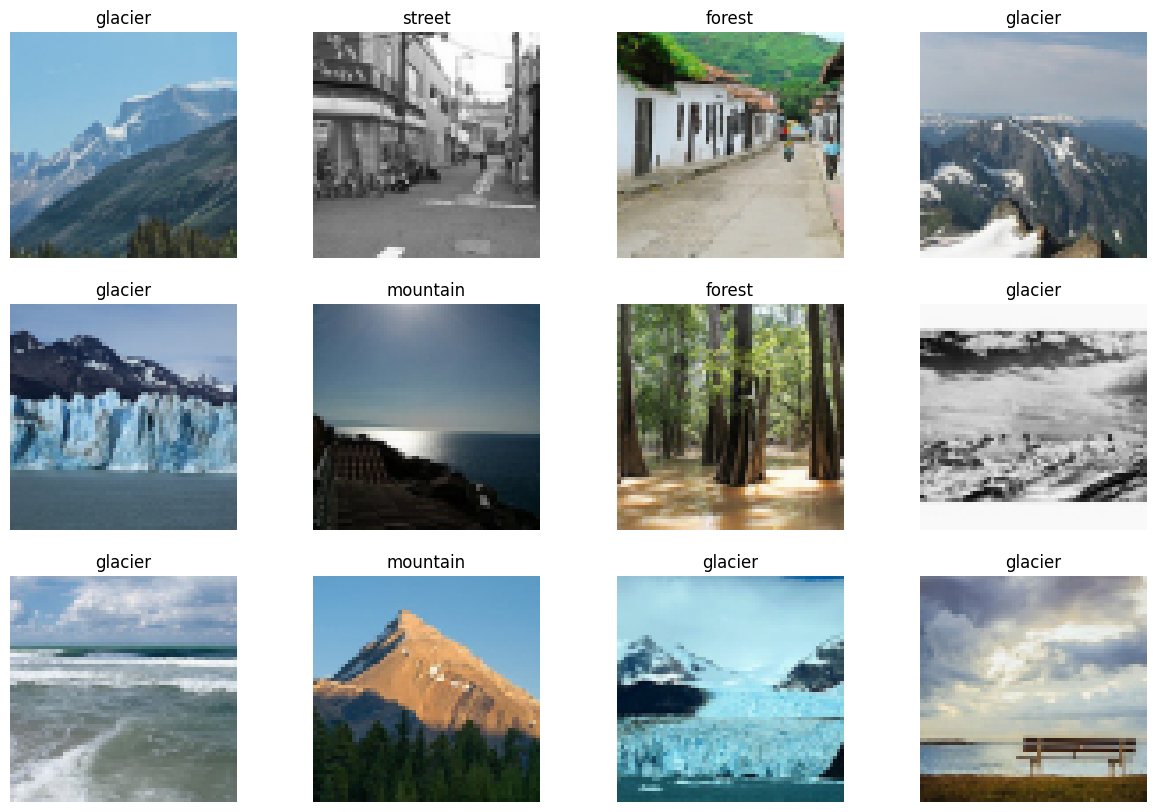

In [29]:
plt.figure(figsize=(15,10))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i])
    plt.axis('off')
    plt.title(label_names[y_pred[i]])
plt.show()

### Plot confusion matrix on a heatmap

In [30]:
from sklearn.metrics import confusion_matrix

<Axes: >

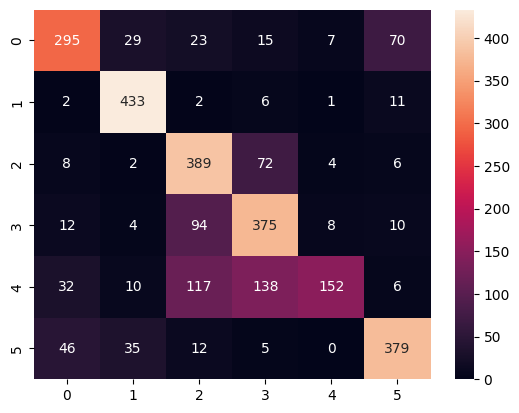

In [31]:
sns.heatmap(data = confusion_matrix(y_test,y_pred), annot=True, fmt='d')